In [1]:
import pandas as pd
import numpy as np
from sklearn. neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("spt.csv")  # Must contain x,y,z,n,nc,d,b,bc

In [3]:
features = ['x', 'y', 'z', 'n', 'nc', 'd', 'b']
target = 'bc'

X = data[features]
y = data[target]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
knn_model = KNeighborsRegressor(n_neighbors=4, weights='distance')
knn_model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=4, weights='distance')

In [6]:
y_pred_test = knn_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)
print("\n📊 KNN Regression Performance on Test Set:")
print(f"  MAE  = {mae:.3f}")
print(f"  RMSE = {rmse:.3f}")
print(f"  R²   = {r2:.3f}")


📊 KNN Regression Performance on Test Set:
  MAE  = 13.874
  RMSE = 25.353
  R²   = 0.987


In [7]:
x_min, x_max = 83.800445, 84.149900  # Example longitude bounds
y_min, y_max = 28.077535, 28.341046  # Example latitude bounds
x_grid = np.arange(x_min, x_max, 0.001)
y_grid = np.arange(y_min, y_max, 0.001)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_points = pd.DataFrame({'x': xx.ravel(), 'y': yy.ravel()})

In [8]:
def interpolate_feature(feature_name):
    knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
    knn.fit(data[['x', 'y']], data[feature_name])
    return knn.predict(grid_points[['x', 'y']])

for feat in ['z', 'n', 'nc', 'd', 'b']:
    grid_points[feat] = interpolate_feature(feat)

In [9]:
X_grid = grid_points[features]
grid_points['predicted_bc'] = knn_model.predict(X_grid)


In [10]:
grid_points[['x', 'y', 'predicted_bc']].to_csv('pokhara_knn_predicted_bc.csv', index=False)
print("\n✅ KNN predicted bearing capacity map saved as 'pokhara_knn_predicted_bc.csv'")


✅ KNN predicted bearing capacity map saved as 'pokhara_knn_predicted_bc.csv'


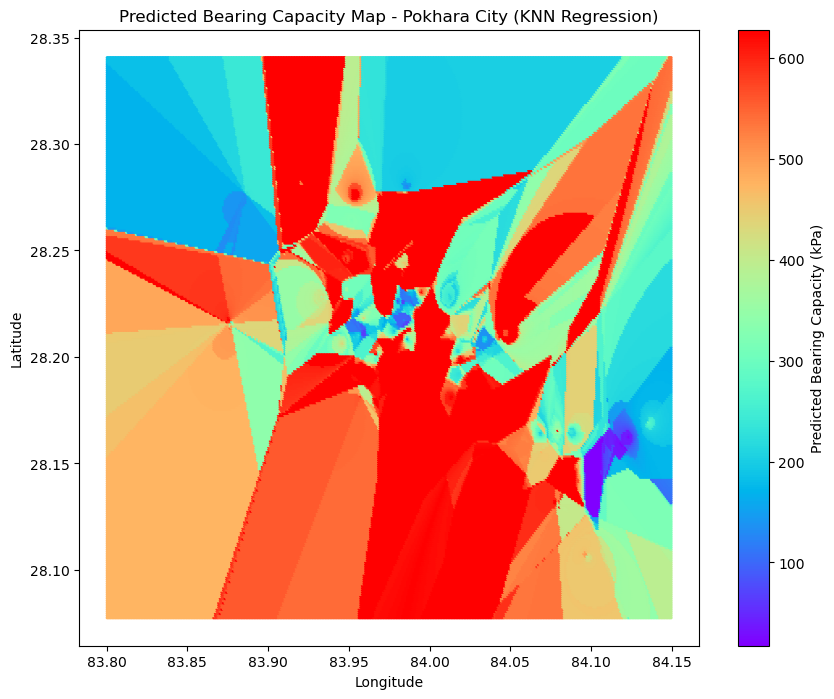

In [11]:
plt.figure(figsize=(10,8))
plt.scatter(grid_points['x'], grid_points['y'], c=grid_points['predicted_bc'], cmap='rainbow', s=2)
plt.colorbar(label='Predicted Bearing Capacity (kPa)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Bearing Capacity Map - Pokhara City (KNN Regression)')
plt.show()

In [12]:
y_pred_on_known = knn_model.predict(X)  # X = original input features from spt.csv
y_true = y.values                       # Original observed bearing capacity

In [13]:
mae_knn = mean_absolute_error(y_true, y_pred_on_known)
rmse_knn = np.sqrt(mean_squared_error(y_true, y_pred_on_known))
r2_knn = r2_score(y_true, y_pred_on_known)

print("\n📊 KNN Performance on Original Observed Data Points:")
print(f"  MAE  = {mae_knn:.3f}")
print(f"  RMSE = {rmse_knn:.3f}")
print(f"  R²   = {r2_knn:.3f}")


📊 KNN Performance on Original Observed Data Points:
  MAE  = 2.775
  RMSE = 11.338
  R²   = 0.997


In [14]:
# Predict bearing capacity at original known points
y_pred_on_known = knn_model.predict(X) #X is the original dataset
y_true = y.values

# Calculate performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_knn = mean_absolute_error(y_true, y_pred_on_known)
rmse_knn = np.sqrt(mean_squared_error(y_true, y_pred_on_known))
r2_knn = r2_score(y_true, y_pred_on_known)


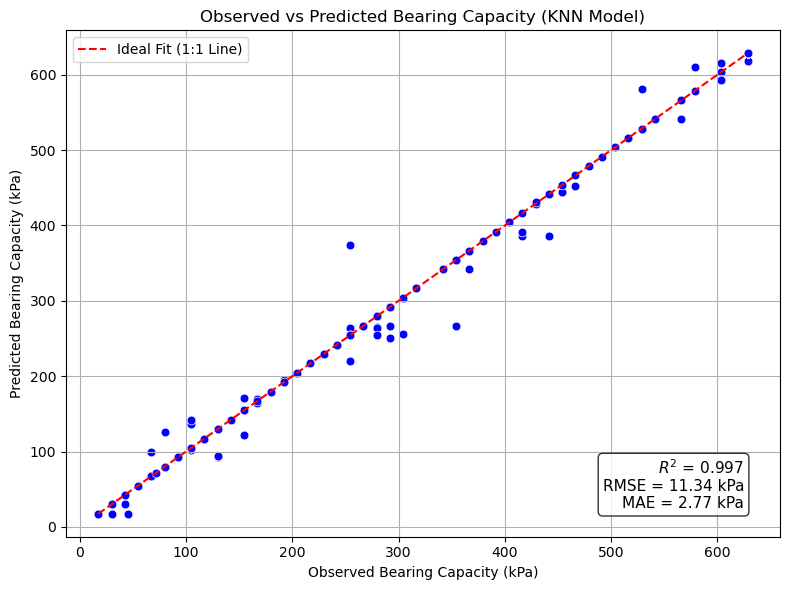

In [15]:
metrics_text = (
    f"$R^2$ = {r2_knn:.3f}\n"
    f"RMSE = {rmse_knn:.2f} kPa\n"
    f"MAE = {mae_knn:.2f} kPa"
)

# Create scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_true, y=y_pred_on_known, color='blue', s=40)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', label='Ideal Fit (1:1 Line)')

# Place metrics in bottom-right corner
plt.text(0.95, 0.05, metrics_text,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Labels and title
plt.xlabel("Observed Bearing Capacity (kPa)")
plt.ylabel("Predicted Bearing Capacity (kPa)")
plt.title("Observed vs Predicted Bearing Capacity (KNN Model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("spt.csv")  # Must contain x,y,z,n,nc,d,b,bc
features = ['x', 'y', 'z', 'n', 'nc', 'd', 'b']
target = 'bc'

X = data[features]
y = data[target]

def get_unit(param):
    units = {
        'x': '°', 'y': '°', 'z': 'm',
        'n': 'blows/30cm', 'nc': 'blows/30cm', 
        'd': 'm', 'b': 'm', 'bc': 'kPa'
    }
    return units.get(param, '-')

print("\n" + "="*80)
print("STATISTICAL CHARACTERIZATION OF GEOTECHNICAL DATABASE (n=410 boreholes)")
print("="*80)

stats_data = []
for feature in features + [target]:
    stats = data[feature].describe()
    stats_data.append({
        'Parameter': feature.upper(),
        'Unit': get_unit(feature),
        'Min': stats['min'],
        'Max': stats['max'],
        'Mean': stats['mean'],
        'Std': stats['std'],
        'CV': stats['std'] / stats['mean'] if stats['mean'] != 0 else 0
    })

stats_df = pd.DataFrame(stats_data)

def format_float(x):
    if isinstance(x, float):
        return f"{x:.3f}"
    return x

print("\nDetailed Statistical Summary:")
print("-" * 100)
print(stats_df.to_string(index=False, formatters={
    'Min': format_float,
    'Max': format_float, 
    'Mean': format_float,
    'Std': format_float,
    'CV': format_float
}))
print("-" * 100)

print(f"\n📊 DATASET CHARACTERISTICS:")
print(f"• Total boreholes: {len(data)}")
print(f"• Spatial coverage: {data['x'].min():.3f}° to {data['x'].max():.3f}° Longitude")
print(f"• Spatial coverage: {data['y'].min():.3f}° to {data['y'].max():.3f}° Latitude") 
print(f"• Data completeness: {100 - data.isnull().sum().sum()/len(data)/len(data.columns)*100:.1f}%")
print(f"• Feature correlation with target:")
for feature in features:
    corr = np.corrcoef(data[feature], data[target])[0,1]
    print(f"  - {feature}: {corr:.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn_model = KNeighborsRegressor(n_neighbors=4, weights='distance')
knn_model.fit(X, y)

